In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [4]:
train_df = pd.read_csv("C:/Users/princ/Downloads/sent_train (1).csv")
valid_df  = pd.read_csv("C:/Users/princ/Downloads/sent_valid (1).csv")

LABEL_MAP = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("\nTrain sample:")
train_df.head()

Train shape: (9543, 2)
Valid shape: (2388, 2)

Train sample:


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


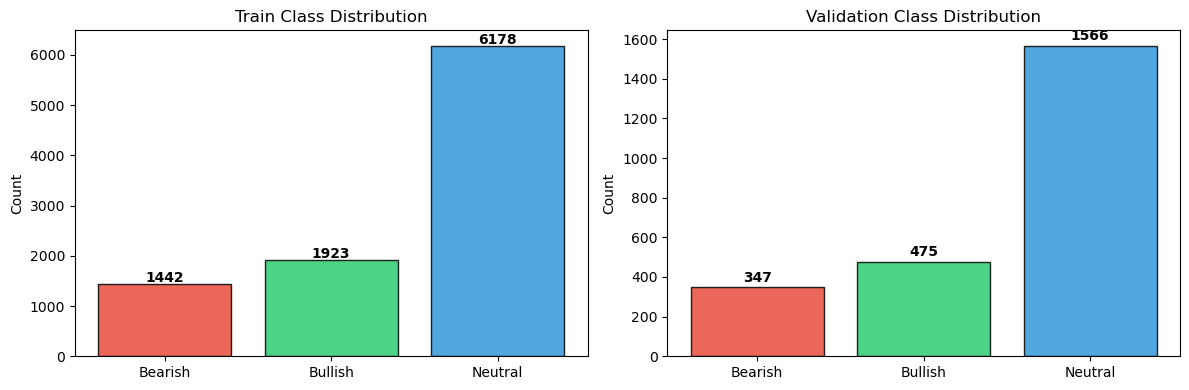

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, title) in zip(axes, [(train_df, 'Train'), (valid_df, 'Validation')]):
    counts = df['label'].value_counts().sort_index()
    labels = [LABEL_MAP[i] for i in counts.index]
    colors = ['#e74c3c', '#2ecc71', '#3498db']
    ax.bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{title} Class Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)                # remove @mentions
    text = re.sub(r'\$([a-zA-Z]+)', r'\1', text)   # $AAPL → aapl
    text = re.sub(r'#', '', text)                   # remove hashtag symbol
    text = re.sub(r'[^\w\s\']', ' ', text)          # remove punctuation
    text = re.sub(r'\d+', '', text)                 # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()        # collapse spaces
    return text

In [7]:
train_df['clean_text'] = train_df['text'].apply(clean_tweet)
valid_df['clean_text']  = valid_df['text'].apply(clean_tweet)

# Before vs After examples
for lbl in [0, 1, 2]:
    row = train_df[train_df['label'] == lbl].iloc[0]
    print(f"[{LABEL_MAP[lbl]}]")
    print(f"  RAW  : {row['text']}")
    print(f"  CLEAN: {row['clean_text']}")
    print()

[Bearish]
  RAW  : $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
  CLEAN: bynd jpmorgan reels in expectations on beyond meat

[Bullish]
  RAW  : $ALTG: Dougherty & Company starts at Buy
  CLEAN: altg dougherty company starts at buy

[Neutral]
  RAW  : $LB - MKM Partners puts a number on Victoria's Secret https://t.co/VSzHLqLBgE
  CLEAN: lb mkm partners puts a number on victoria's secret



count    9543.00
mean       11.30
std         4.41
min         0.00
25%         8.00
50%        11.00
75%        14.00
max        29.00
Name: token_count, dtype: float64

95th percentile (→ use as MAX_LEN): 20


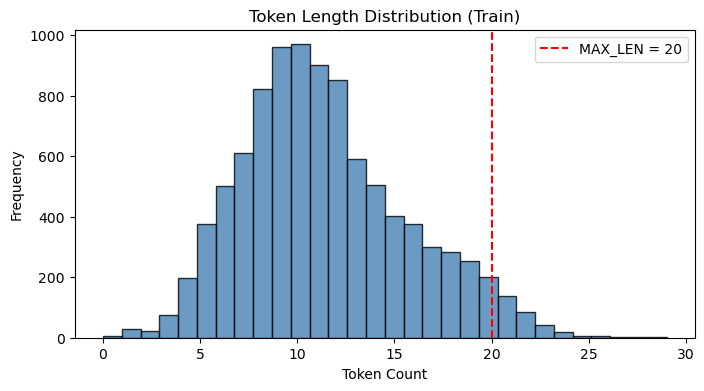

In [8]:
train_df['token_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))
valid_df['token_count']  = valid_df['clean_text'].apply(lambda x: len(x.split()))

print(train_df['token_count'].describe().round(2))
print(f"\n95th percentile (→ use as MAX_LEN): {train_df['token_count'].quantile(0.95):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(train_df['token_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(20, color='red', linestyle='--', label='MAX_LEN = 20')
plt.title('Token Length Distribution (Train)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [9]:
# Drop rows that became empty after cleaning
train_df = train_df[train_df['clean_text'].str.strip() != ''].reset_index(drop=True)
valid_df  = valid_df[valid_df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"Train after cleaning: {len(train_df)} rows")
print(f"Valid after cleaning : {len(valid_df)} rows")

# Save for reuse in later phases
train_df.to_csv('train_clean.csv', index=False)
valid_df.to_csv('valid_clean.csv',  index=False)
print("\n✅ Saved train_clean.csv and valid_clean.csv")

Train after cleaning: 9536 rows
Valid after cleaning : 2388 rows

✅ Saved train_clean.csv and valid_clean.csv


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [11]:
MAX_LEN  = 20      # covers 95% of tweets
MIN_FREQ = 2       # ignore words seen only once
PAD_IDX  = 0      # padding token index
UNK_IDX  = 1      # unknown token index
BATCH_SIZE = 64

In [12]:
def build_vocab(texts, min_freq=MIN_FREQ):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    # Start index from 2 (0=PAD, 1=UNK reserved)
    vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(train_df['clean_text'])

print(f"Vocabulary size : {len(vocab)}")
print(f"Sample entries  : {list(vocab.items())[2:12]}")

Vocabulary size : 7296
Sample entries  : [('bynd', 2), ('jpmorgan', 3), ('reels', 4), ('in', 5), ('expectations', 6), ('on', 7), ('beyond', 8), ('meat', 9), ('ccl', 10), ('rcl', 11)]


In [13]:
def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    indices = [vocab.get(tok, UNK_IDX) for tok in tokens]
    # Pad to max_len
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices

# Quick sanity check
sample_text  = train_df['clean_text'].iloc[0]
sample_enc   = encode_text(sample_text, vocab)
print(f"Text   : {sample_text}")
print(f"Encoded: {sample_enc}")
print(f"Length : {len(sample_enc)}")

Text   : bynd jpmorgan reels in expectations on beyond meat
Encoded: [2, 3, 4, 5, 6, 7, 8, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length : 20


In [14]:
class TweetDataset(Dataset):
    """
    Custom PyTorch Dataset for financial tweet sentiment.
    Returns (encoded_text_tensor, label_tensor) for each sample.
    """
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.encodings = [
            encode_text(text, vocab, max_len)
            for text in df['clean_text']
        ]
        self.labels = df['label'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.encodings[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx],    dtype=torch.long)
        return x, y

In [15]:
train_dataset = TweetDataset(train_df, vocab)
valid_dataset = TweetDataset(valid_df, vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

# Check one batch shape
xb, yb = next(iter(train_loader))
print(f"\nBatch input shape : {xb.shape}  → (batch_size, max_len)")
print(f"Batch label shape : {yb.shape}  → (batch_size,)")
print(f"Sample labels     : {yb[:8].tolist()}")

Train batches : 149
Valid batches : 38

Batch input shape : torch.Size([64, 20])  → (batch_size, max_len)
Batch label shape : torch.Size([64])  → (batch_size,)
Sample labels     : [1, 2, 0, 0, 2, 0, 2, 0]


In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights (Bearish, Bullish, Neutral):")
print(class_weights_tensor)
print("\n(Higher weight = model penalized more for missing that class)")

Class weights (Bearish, Bullish, Neutral):
tensor([2.2043, 1.6530, 0.5151])

(Higher weight = model penalized more for missing that class)


In [17]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move class weights to device
class_weights_tensor = class_weights_tensor.to(device)

Using device: cpu


In [19]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, dropout=0.3):
        super(SimpleRNN, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx        # PAD tokens contribute zero gradient
        )
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,          # input shape: (batch, seq, features)
            nonlinearity='tanh'
        )
        self.dropout  = nn.Dropout(dropout)
        self.fc       = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))       # (batch, seq_len, embed_dim)
        _, hidden = self.rnn(embedded)                   # hidden: (1, batch, hidden_dim)
        hidden    = hidden.squeeze(0)                    # (batch, hidden_dim)
        out       = self.fc(self.dropout(hidden))        # (batch, 3)
        return out

In [20]:
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 128
HIDDEN_DIM  = 256
OUTPUT_DIM  = 3       # Bearish, Bullish, Neutral
DROPOUT     = 0.3
N_EPOCHS    = 10
LR          = 1e-3

rnn_model = SimpleRNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=PAD_IDX,
    dropout=DROPOUT
).to(device)

print(rnn_model)
total_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

SimpleRNN(
  (embedding): Embedding(7296, 128, padding_idx=0)
  (rnn): RNN(128, 256, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Trainable parameters: 1,033,475


In [21]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)  # handles class imbalance
optimizer = optim.Adam(rnn_model.parameters(), lr=LR)

In [22]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Run one full training epoch, return avg loss."""
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    """Evaluate model, return loss, accuracy, macro-F1, all predictions & labels."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds       = model(xb)
            loss        = criterion(preds, yb)
            total_loss += loss.item()
            predicted   = preds.argmax(dim=1)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1, all_preds, all_labels

In [23]:
print("Training Simple RNN...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>7}")
print("-" * 55)

rnn_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1    = 0
best_rnn_state = None

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(rnn_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(rnn_model, valid_loader, criterion, device)

    rnn_history['train_loss'].append(train_loss)
    rnn_history['val_loss'].append(val_loss)
    rnn_history['val_acc'].append(val_acc)
    rnn_history['val_f1'].append(val_f1)

    # Save best model weights based on macro F1
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_rnn_state = rnn_model.state_dict()

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>7.4f}")

print(f"\n Best Validation Macro F1: {best_val_f1:.4f}")

Training Simple RNN...
Epoch | Train Loss | Val Loss | Val Acc |  Val F1
-------------------------------------------------------
    1 |     1.0947 |   1.0850 |  0.4673 |  0.3527
    2 |     1.0517 |   1.0190 |  0.5712 |  0.3845
    3 |     1.0456 |   0.9932 |  0.5854 |  0.4317
    4 |     1.0237 |   1.0095 |  0.6064 |  0.4268
    5 |     1.0079 |   0.9473 |  0.6147 |  0.4606
    6 |     0.9713 |   0.9290 |  0.6315 |  0.4892
    7 |     0.9451 |   0.8807 |  0.6579 |  0.5033
    8 |     0.9048 |   0.8801 |  0.6470 |  0.5132
    9 |     0.8939 |   0.8648 |  0.6759 |  0.5144
   10 |     0.8669 |   0.8572 |  0.6616 |  0.5076

 Best Validation Macro F1: 0.5144


In [24]:
# Load best checkpoint
rnn_model.load_state_dict(best_rnn_state)

_, val_acc, val_f1, val_preds, val_labels = evaluate(rnn_model, valid_loader, criterion, device)

print("=" * 55)
print("SIMPLE RNN — FINAL EVALUATION ON VALIDATION SET")
print("=" * 55)
print(classification_report(val_labels, val_preds, target_names=['Bearish','Bullish','Neutral']))

SIMPLE RNN — FINAL EVALUATION ON VALIDATION SET
              precision    recall  f1-score   support

     Bearish       0.25      0.16      0.19       347
     Bullish       0.42      0.69      0.52       475
     Neutral       0.86      0.77      0.81      1566

    accuracy                           0.66      2388
   macro avg       0.51      0.54      0.51      2388
weighted avg       0.68      0.66      0.66      2388



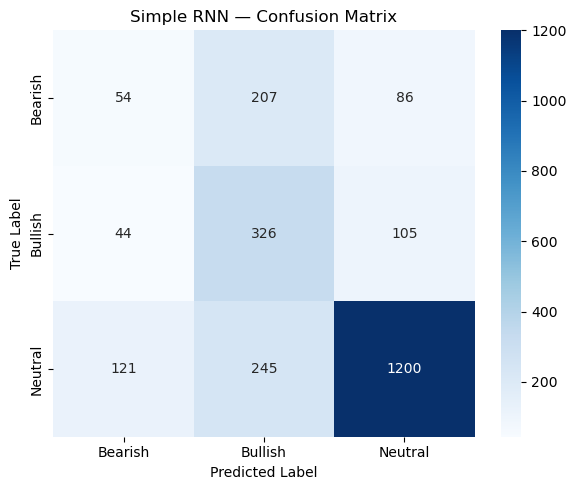

In [25]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bearish','Bullish','Neutral'],
            yticklabels=['Bearish','Bullish','Neutral'])
plt.title('Simple RNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

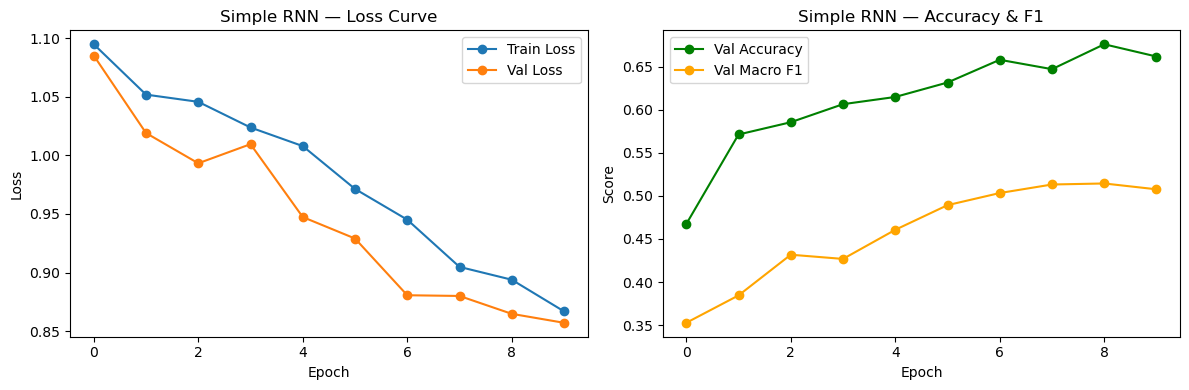

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rnn_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(rnn_history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Simple RNN — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(rnn_history['val_acc'], label='Val Accuracy', marker='o', color='green')
axes[1].plot(rnn_history['val_f1'],  label='Val Macro F1', marker='o', color='orange')
axes[1].set_title('Simple RNN — Accuracy & F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
rnn_results = {
    'model'   : 'Simple RNN',
    'accuracy': val_acc,
    'macro_f1': val_f1
}
print("Saved RNN results:", rnn_results)

Saved RNN results: {'model': 'Simple RNN', 'accuracy': 0.661641541038526, 'macro_f1': 0.507599096770953}


In [30]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, 
                 pad_idx, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,       # stacked LSTM layers
            batch_first=True,
            dropout=dropout,             # dropout between LSTM layers
            bidirectional=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded        = self.dropout(self.embedding(x))    # (batch, seq_len, embed_dim)
        out, (hidden,_) = self.lstm(embedded)                # hidden: (num_layers, batch, hidden_dim)
        hidden          = hidden[-1]                         # take last layer's hidden state
        out             = self.fc(self.dropout(hidden))      # (batch, 3)
        return out

In [31]:
lstm_model = LSTMModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=PAD_IDX,
    num_layers=2,
    dropout=DROPOUT
).to(device)

print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

LSTMModel(
  (embedding): Embedding(7296, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Trainable parameters: 1,856,259


In [32]:
criterion_lstm = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=LR)

In [33]:
print("Training LSTM...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>7}")
print("-" * 55)

lstm_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1_lstm  = 0
best_lstm_state   = None

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(lstm_model, train_loader, optimizer_lstm, criterion_lstm, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(lstm_model, valid_loader, criterion_lstm, device)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['val_acc'].append(val_acc)
    lstm_history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1_lstm:
        best_val_f1_lstm = val_f1
        best_lstm_state  = lstm_model.state_dict()

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>7.4f}")

print(f"\n Best Validation Macro F1: {best_val_f1_lstm:.4f}")

Training LSTM...
Epoch | Train Loss | Val Loss | Val Acc |  Val F1
-------------------------------------------------------
    1 |     1.0401 |   0.9109 |  0.6558 |  0.5329
    2 |     0.9213 |   0.8356 |  0.6884 |  0.5865
    3 |     0.8090 |   0.7354 |  0.7299 |  0.6280
    4 |     0.7080 |   0.6845 |  0.7605 |  0.6710
    5 |     0.6208 |   0.7250 |  0.7420 |  0.6658
    6 |     0.5478 |   0.7609 |  0.7768 |  0.6912
    7 |     0.4884 |   0.6658 |  0.7621 |  0.7001
    8 |     0.4250 |   0.6775 |  0.7755 |  0.7075
    9 |     0.3745 |   0.7251 |  0.8003 |  0.7257
   10 |     0.3221 |   0.6924 |  0.8065 |  0.7399

 Best Validation Macro F1: 0.7399


In [34]:
lstm_model.load_state_dict(best_lstm_state)

_, val_acc_lstm, val_f1_lstm, val_preds_lstm, val_labels_lstm = evaluate(
    lstm_model, valid_loader, criterion_lstm, device
)

print("=" * 55)
print("LSTM — FINAL EVALUATION ON VALIDATION SET")
print("=" * 55)
print(classification_report(
    val_labels_lstm, val_preds_lstm,
    target_names=['Bearish', 'Bullish', 'Neutral']
))

LSTM — FINAL EVALUATION ON VALIDATION SET
              precision    recall  f1-score   support

     Bearish       0.62      0.65      0.63       347
     Bullish       0.68      0.74      0.71       475
     Neutral       0.89      0.86      0.88      1566

    accuracy                           0.81      2388
   macro avg       0.73      0.75      0.74      2388
weighted avg       0.81      0.81      0.81      2388



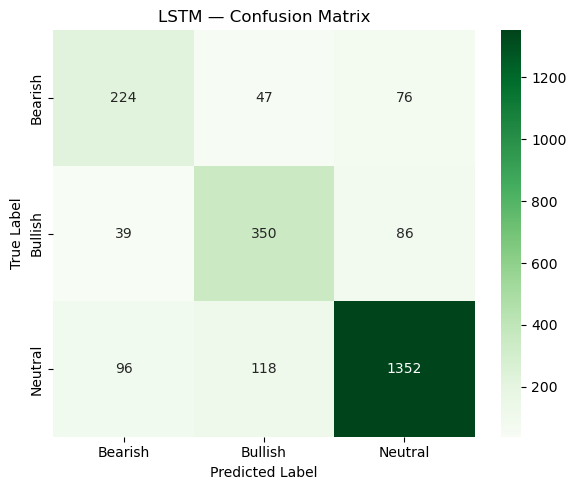

In [35]:
cm_lstm = confusion_matrix(val_labels_lstm, val_preds_lstm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bearish','Bullish','Neutral'],
            yticklabels=['Bearish','Bullish','Neutral'])
plt.title('LSTM — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

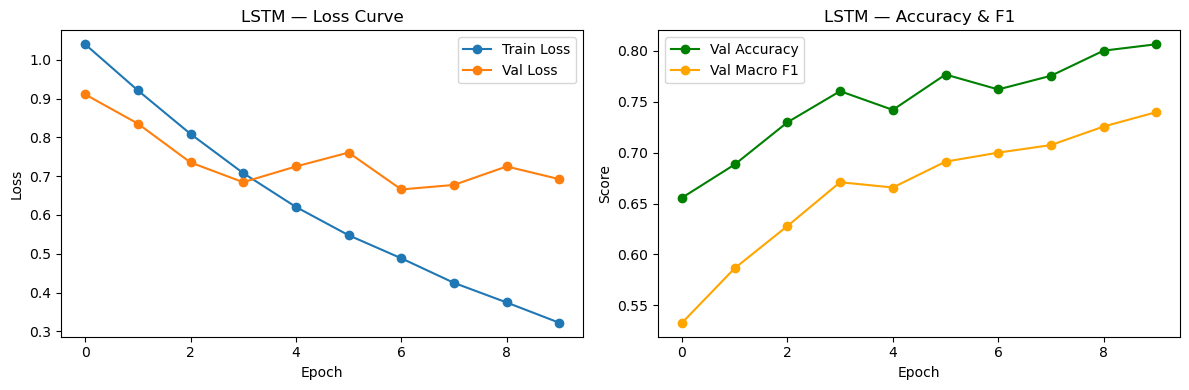

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lstm_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(lstm_history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('LSTM — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(lstm_history['val_acc'], label='Val Accuracy', marker='o', color='green')
axes[1].plot(lstm_history['val_f1'],  label='Val Macro F1', marker='o', color='orange')
axes[1].set_title('LSTM — Accuracy & F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
lstm_results = {
    'model'   : 'LSTM',
    'accuracy': val_acc_lstm,
    'macro_f1': val_f1_lstm
}
print("Saved LSTM results:", lstm_results)

Saved LSTM results: {'model': 'LSTM', 'accuracy': 0.8065326633165829, 'macro_f1': 0.7398512305027886}


In [38]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,
                 pad_idx, num_layers=2, dropout=0.3):
        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,      # stacked GRU layers
            batch_first=True,
            dropout=dropout,            # dropout between GRU layers
            bidirectional=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded       = self.dropout(self.embedding(x))   # (batch, seq_len, embed_dim)
        out, hidden    = self.gru(embedded)                 # hidden: (num_layers, batch, hidden_dim)
        hidden         = hidden[-1]                         # take last layer's hidden state
        out            = self.fc(self.dropout(hidden))      # (batch, 3)
        return out

In [39]:
gru_model = GRUModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=PAD_IDX,
    num_layers=2,
    dropout=DROPOUT
).to(device)

print(gru_model)
total_params = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

GRUModel(
  (embedding): Embedding(7296, 128, padding_idx=0)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Trainable parameters: 1,625,859


In [40]:
criterion_gru = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=LR)

In [41]:
print("Training GRU...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>7}")
print("-" * 55)

gru_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1_gru = 0
best_gru_state  = None

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(gru_model, train_loader, optimizer_gru, criterion_gru, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(gru_model, valid_loader, criterion_gru, device)

    gru_history['train_loss'].append(train_loss)
    gru_history['val_loss'].append(val_loss)
    gru_history['val_acc'].append(val_acc)
    gru_history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1_gru:
        best_val_f1_gru = val_f1
        best_gru_state  = gru_model.state_dict()

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>7.4f}")

print(f"\n Best Validation Macro F1: {best_val_f1_gru:.4f}")

Training GRU...
Epoch | Train Loss | Val Loss | Val Acc |  Val F1
-------------------------------------------------------
    1 |     1.0512 |   0.8865 |  0.6776 |  0.5523
    2 |     0.8832 |   0.7699 |  0.7123 |  0.6143
    3 |     0.7482 |   0.7127 |  0.7073 |  0.6336
    4 |     0.6337 |   0.6546 |  0.7655 |  0.6900
    5 |     0.5502 |   0.7648 |  0.6805 |  0.6374
    6 |     0.4647 |   0.6896 |  0.8028 |  0.7257
    7 |     0.3986 |   0.6948 |  0.7906 |  0.7115
    8 |     0.3345 |   0.7111 |  0.7898 |  0.7193
    9 |     0.2967 |   0.7262 |  0.7940 |  0.7318
   10 |     0.2565 |   0.8736 |  0.7776 |  0.7097

 Best Validation Macro F1: 0.7318


In [42]:
gru_model.load_state_dict(best_gru_state)

_, val_acc_gru, val_f1_gru, val_preds_gru, val_labels_gru = evaluate(
    gru_model, valid_loader, criterion_gru, device
)

print("=" * 55)
print("GRU — FINAL EVALUATION ON VALIDATION SET")
print("=" * 55)
print(classification_report(
    val_labels_gru, val_preds_gru,
    target_names=['Bearish', 'Bullish', 'Neutral']
))

GRU — FINAL EVALUATION ON VALIDATION SET
              precision    recall  f1-score   support

     Bearish       0.55      0.63      0.59       347
     Bullish       0.64      0.74      0.69       475
     Neutral       0.90      0.82      0.86      1566

    accuracy                           0.78      2388
   macro avg       0.69      0.73      0.71      2388
weighted avg       0.79      0.78      0.78      2388



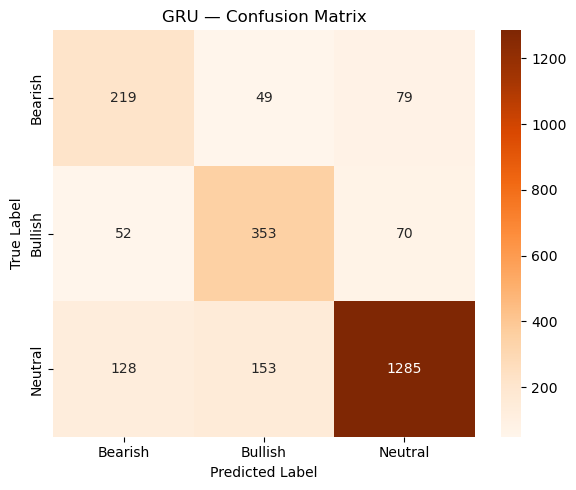

In [43]:
cm_gru = confusion_matrix(val_labels_gru, val_preds_gru)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bearish','Bullish','Neutral'],
            yticklabels=['Bearish','Bullish','Neutral'])
plt.title('GRU — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

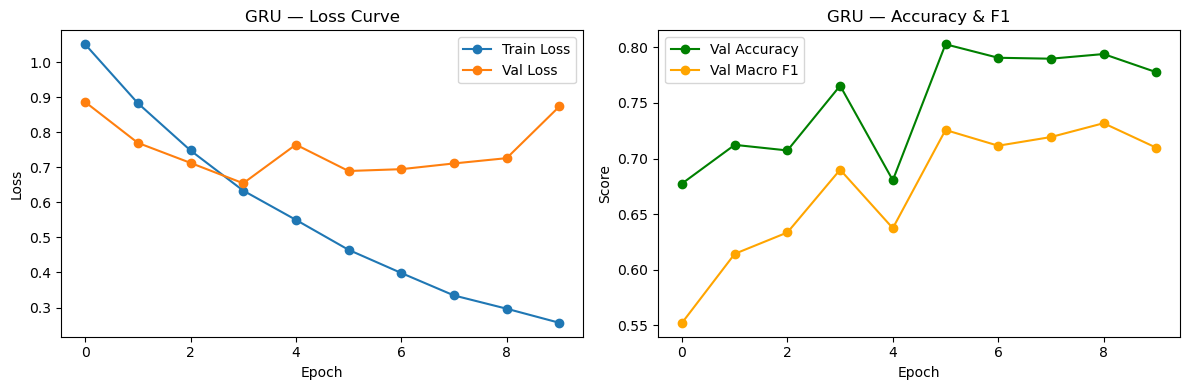

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(gru_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(gru_history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('GRU — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(gru_history['val_acc'], label='Val Accuracy', marker='o', color='green')
axes[1].plot(gru_history['val_f1'],  label='Val Macro F1', marker='o', color='orange')
axes[1].set_title('GRU — Accuracy & F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
gru_results = {
    'model'   : 'GRU',
    'accuracy': val_acc_gru,
    'macro_f1': val_f1_gru
}
print("Saved GRU results:", gru_results)

Saved GRU results: {'model': 'GRU', 'accuracy': 0.7776381909547738, 'macro_f1': 0.7097449757209251}


In [46]:
results = [rnn_results, lstm_results, gru_results]
results_df = pd.DataFrame(results)
results_df['accuracy'] = results_df['accuracy'].round(4)
results_df['macro_f1'] = results_df['macro_f1'].round(4)

print("=" * 45)
print("     ALL MODELS — COMPARISON SUMMARY")
print("=" * 45)
print(results_df.to_string(index=False))
print("=" * 45)
best_model = results_df.loc[results_df['macro_f1'].idxmax(), 'model']
print(f"\n Best Model by Macro F1: {best_model}")

     ALL MODELS — COMPARISON SUMMARY
     model  accuracy  macro_f1
Simple RNN    0.6616    0.5076
      LSTM    0.8065    0.7399
       GRU    0.7776    0.7097

 Best Model by Macro F1: LSTM


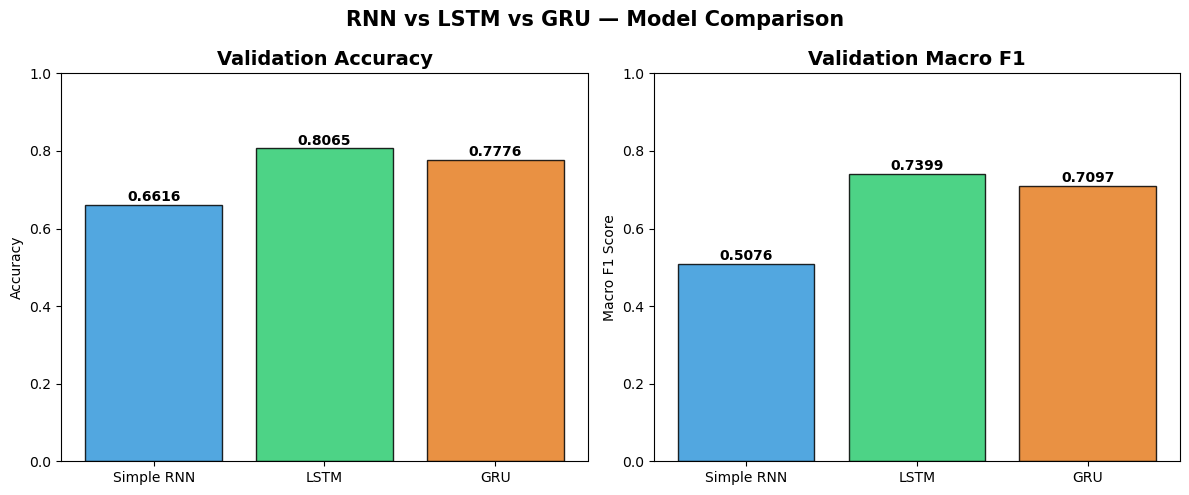

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models  = results_df['model'].tolist()
acc     = results_df['accuracy'].tolist()
f1      = results_df['macro_f1'].tolist()
colors  = ['#3498db', '#2ecc71', '#e67e22']

# Accuracy
bars = axes[0].bar(models, acc, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, acc):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# Macro F1
bars = axes[1].bar(models, f1, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Validation Macro F1', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, f1):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('RNN vs LSTM vs GRU — Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

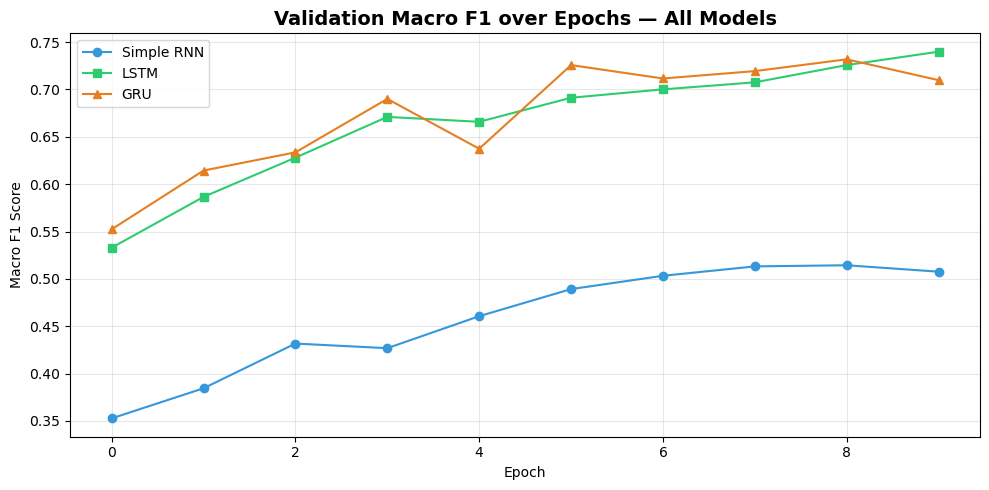

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history['val_f1'],  label='Simple RNN', marker='o', color='#3498db')
plt.plot(lstm_history['val_f1'], label='LSTM',        marker='s', color='#2ecc71')
plt.plot(gru_history['val_f1'],  label='GRU',         marker='^', color='#e67e22')

plt.title('Validation Macro F1 over Epochs — All Models', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Macro F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

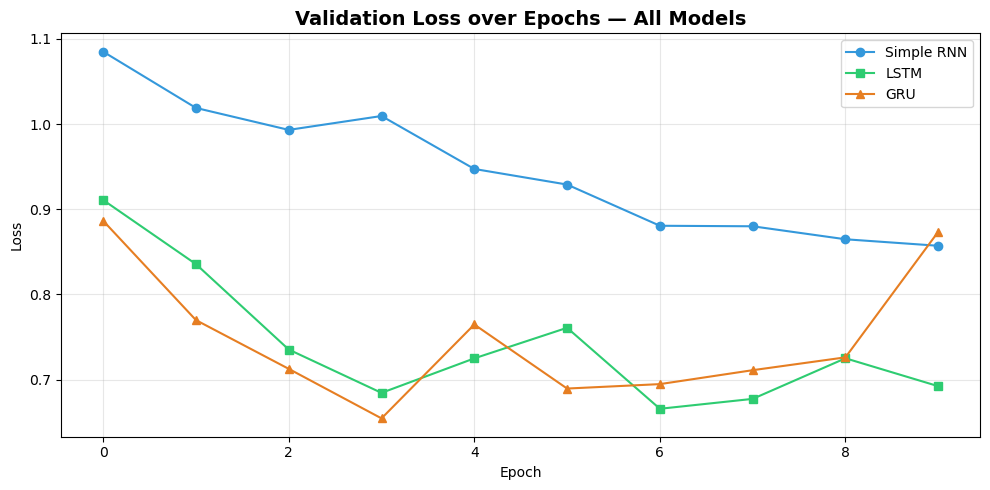

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history['val_loss'],  label='Simple RNN', marker='o', color='#3498db')
plt.plot(lstm_history['val_loss'], label='LSTM',        marker='s', color='#2ecc71')
plt.plot(gru_history['val_loss'],  label='GRU',         marker='^', color='#e67e22')

plt.title('Validation Loss over Epochs — All Models', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

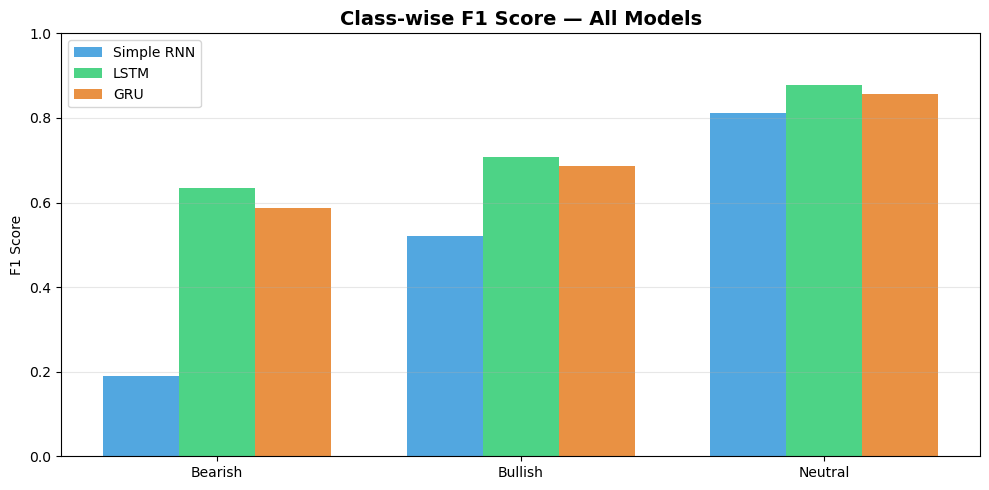

In [50]:
from sklearn.metrics import f1_score

# Per-class F1 for each model
def class_f1(labels, preds):
    return f1_score(labels, preds, average=None, labels=[0, 1, 2])

rnn_f1_per_class  = class_f1(val_labels,      val_preds)
lstm_f1_per_class = class_f1(val_labels_lstm,  val_preds_lstm)
gru_f1_per_class  = class_f1(val_labels_gru,   val_preds_gru)

class_names = ['Bearish', 'Bullish', 'Neutral']
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, rnn_f1_per_class,  width, label='Simple RNN', color='#3498db', alpha=0.85)
ax.bar(x,         lstm_f1_per_class, width, label='LSTM',        color='#2ecc71', alpha=0.85)
ax.bar(x + width, gru_f1_per_class,  width, label='GRU',         color='#e67e22', alpha=0.85)

ax.set_title('Class-wise F1 Score — All Models', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

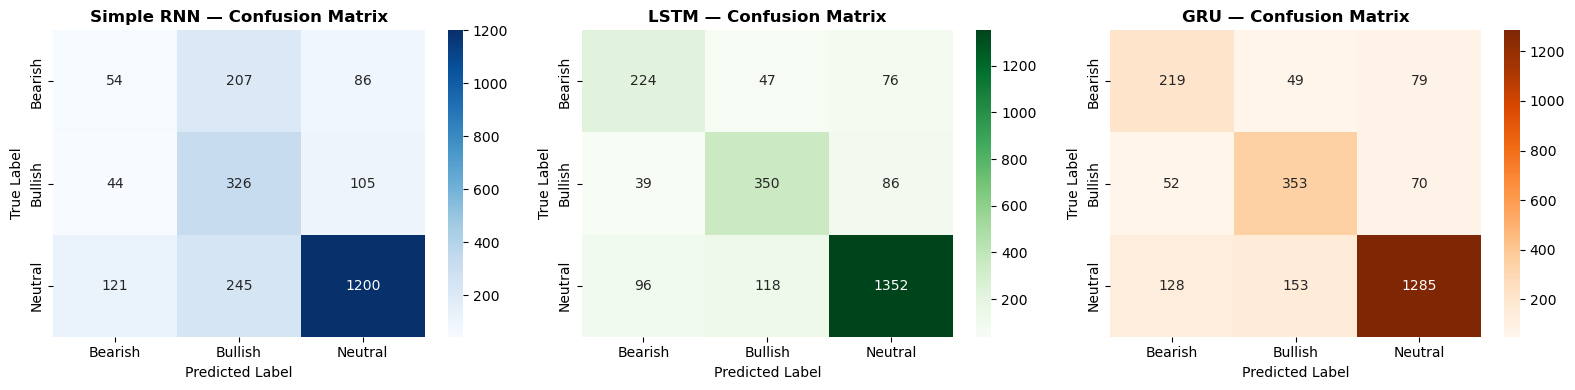

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, cm, title, cmap in zip(
    axes,
    [cm, cm_lstm, cm_gru],
    ['Simple RNN', 'LSTM', 'GRU'],
    ['Blues', 'Greens', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'])
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [52]:
# Save the best performing RNN-based model
best_results = max(results, key=lambda x: x['macro_f1'])
print(f"Best model: {best_results['model']}")

# Save based on which won
if best_results['model'] == 'GRU':
    torch.save(best_gru_state,  'best_rnn_model.pt')
    best_arch = 'GRU'
elif best_results['model'] == 'LSTM':
    torch.save(best_lstm_state, 'best_rnn_model.pt')
    best_arch = 'LSTM'
else:
    torch.save(best_rnn_state,  'best_rnn_model.pt')
    best_arch = 'SimpleRNN'

# Save vocab and config for inference
import pickle
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

config = {
    'vocab_size' : VOCAB_SIZE,
    'embed_dim'  : EMBED_DIM,
    'hidden_dim' : HIDDEN_DIM,
    'output_dim' : OUTPUT_DIM,
    'pad_idx'    : PAD_IDX,
    'max_len'    : MAX_LEN,
    'best_arch'  : best_arch
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print(f"✅ Saved best_rnn_model.pt  ({best_arch})")
print("✅ Saved vocab.pkl")
print("✅ Saved model_config.pkl")

Best model: LSTM
✅ Saved best_rnn_model.pt  (LSTM)
✅ Saved vocab.pkl
✅ Saved model_config.pkl


In [53]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

In [54]:
MODEL_NAME = "ProsusAI/finbert"   # pretrained on financial text

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded : {MODEL_NAME}")
print(f"Vocab size        : {tokenizer.vocab_size}")

# Test tokenizer on a sample tweet
sample = "JPMorgan cuts price target on Apple citing weak demand"
tokens = tokenizer(sample, truncation=True, max_length=64)
print(f"\nSample encoding keys : {list(tokens.keys())}")
print(f"Input IDs            : {tokens['input_ids']}")
print(f"Token count          : {len(tokens['input_ids'])}")

Tokenizer loaded : ProsusAI/finbert
Vocab size        : 30522

Sample encoding keys : ['input_ids', 'token_type_ids', 'attention_mask']
Input IDs            : [101, 16545, 5302, 16998, 7659, 3976, 4539, 2006, 6207, 8951, 5410, 5157, 102]
Token count          : 13


In [55]:
class BERTDataset(Dataset):
    """
    Tokenizes tweets using FinBERT tokenizer.
    Returns input_ids, attention_mask, and label tensors.
    """
    def __init__(self, df, tokenizer, max_len=64):
        self.texts     = df['clean_text'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),       # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),   # (max_len,)
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [56]:
BERT_MAX_LEN   = 64
BERT_BATCH     = 16    # smaller batch — BERT is memory heavy

bert_train_dataset = BERTDataset(train_df, tokenizer, max_len=BERT_MAX_LEN)
bert_valid_dataset = BERTDataset(valid_df, tokenizer, max_len=BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BERT_BATCH, shuffle=True)
bert_valid_loader = DataLoader(bert_valid_dataset, batch_size=BERT_BATCH, shuffle=False)

print(f"BERT Train batches : {len(bert_train_loader)}")
print(f"BERT Valid batches : {len(bert_valid_loader)}")

# Check one batch
batch = next(iter(bert_train_loader))
print(f"\ninput_ids shape      : {batch['input_ids'].shape}")
print(f"attention_mask shape : {batch['attention_mask'].shape}")
print(f"labels shape         : {batch['label'].shape}")

BERT Train batches : 596
BERT Valid batches : 150

input_ids shape      : torch.Size([16, 64])
attention_mask shape : torch.Size([16, 64])
labels shape         : torch.Size([16])


In [57]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,           # Bearish, Bullish, Neutral
    ignore_mismatched_sizes=True
)

bert_model = bert_model.to(device)

total_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"FinBERT loaded ✅")
print(f"Trainable parameters: {total_params:,}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded ✅
Trainable parameters: 109,484,547


In [58]:
BERT_EPOCHS = 4         # BERT converges fast — 3~5 epochs is enough
BERT_LR     = 2e-5      # standard fine-tuning LR for BERT

optimizer_bert = AdamW(
    bert_model.parameters(),
    lr=BERT_LR,
    weight_decay=0.01      # L2 regularization
)

total_steps = len(bert_train_loader) * BERT_EPOCHS

# Linear warmup for first 10% of steps, then linear decay
scheduler = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Weighted loss for class imbalance
criterion_bert = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {int(0.1 * total_steps)}")

Total training steps : 2384
Warmup steps         : 238


In [59]:
def train_epoch_bert(model, loader, optimizer, scheduler, criterion, device):
    """One full training epoch for BERT."""
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_bert(model, loader, criterion, device):
    """Evaluate BERT model on a dataloader."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            logits     = outputs.logits
            loss       = criterion(logits, labels)
            total_loss += loss.item()

            predicted = logits.argmax(dim=1)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1, all_preds, all_labels

In [60]:
print("Fine-tuning FinBERT...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>7}")
print("-" * 55)

bert_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1_bert = 0
best_bert_state  = None

for epoch in range(1, BERT_EPOCHS + 1):
    train_loss = train_epoch_bert(
        bert_model, bert_train_loader,
        optimizer_bert, scheduler, criterion_bert, device
    )
    val_loss, val_acc, val_f1, _, _ = evaluate_bert(
        bert_model, bert_valid_loader, criterion_bert, device
    )

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    bert_history['val_acc'].append(val_acc)
    bert_history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1_bert:
        best_val_f1_bert = val_f1
        best_bert_state  = bert_model.state_dict()

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>7.4f}")

print(f"\n Best FinBERT Validation Macro F1: {best_val_f1_bert:.4f}")

Fine-tuning FinBERT...
Epoch | Train Loss | Val Loss | Val Acc |  Val F1
-------------------------------------------------------
    1 |     0.8198 |   0.4740 |  0.8258 |  0.7839
    2 |     0.3887 |   0.4324 |  0.8580 |  0.8174
    3 |     0.2204 |   0.5004 |  0.8706 |  0.8340
    4 |     0.1220 |   0.5680 |  0.8752 |  0.8374

 Best FinBERT Validation Macro F1: 0.8374


In [61]:
bert_model.load_state_dict(best_bert_state)

_, val_acc_bert, val_f1_bert, val_preds_bert, val_labels_bert = evaluate_bert(
    bert_model, bert_valid_loader, criterion_bert, device
)

print("=" * 55)
print("FinBERT — FINAL EVALUATION ON VALIDATION SET")
print("=" * 55)
print(classification_report(
    val_labels_bert, val_preds_bert,
    target_names=['Bearish', 'Bullish', 'Neutral']
))

FinBERT — FINAL EVALUATION ON VALIDATION SET
              precision    recall  f1-score   support

     Bearish       0.73      0.84      0.78       347
     Bullish       0.82      0.81      0.81       475
     Neutral       0.93      0.90      0.92      1566

    accuracy                           0.88      2388
   macro avg       0.83      0.85      0.84      2388
weighted avg       0.88      0.88      0.88      2388



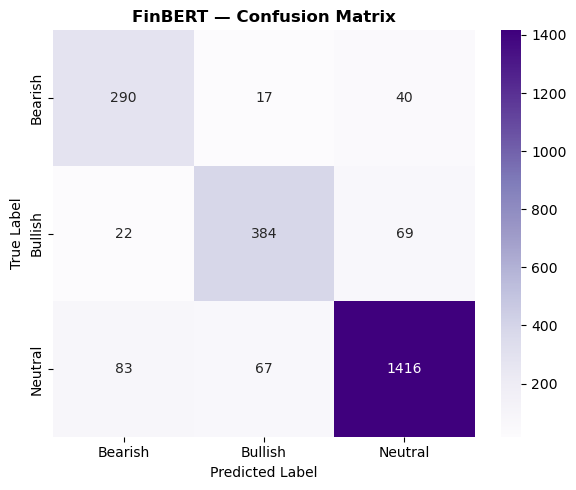

In [62]:
cm_bert = confusion_matrix(val_labels_bert, val_preds_bert)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bearish','Bullish','Neutral'],
            yticklabels=['Bearish','Bullish','Neutral'])
plt.title('FinBERT — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

   FULL COMPARISON — RNN Models vs FinBERT
     model  accuracy  macro_f1
Simple RNN    0.6616    0.5076
      LSTM    0.8065    0.7399
       GRU    0.7776    0.7097
   FinBERT    0.8752    0.8374


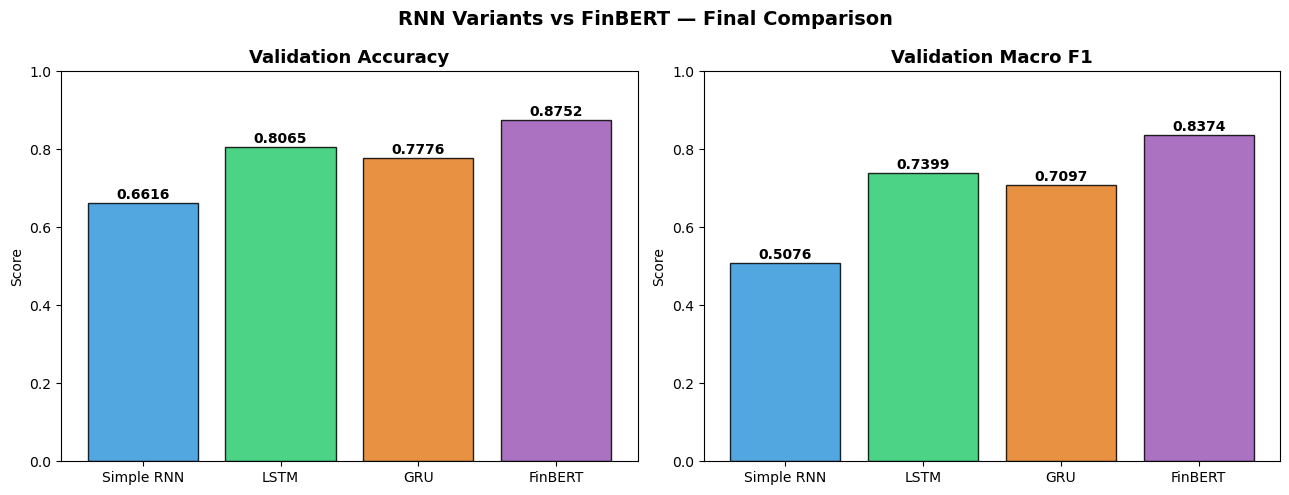

In [63]:
all_results = pd.DataFrame([
    rnn_results,
    lstm_results,
    gru_results,
    {'model': 'FinBERT', 'accuracy': val_acc_bert, 'macro_f1': val_f1_bert}
])

print("=" * 50)
print("   FULL COMPARISON — RNN Models vs FinBERT")
print("=" * 50)
print(all_results.round(4).to_string(index=False))
print("=" * 50)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
models = all_results['model'].tolist()

for ax, metric, title in zip(
    axes,
    ['accuracy', 'macro_f1'],
    ['Validation Accuracy', 'Validation Macro F1']
):
    bars = ax.bar(models, all_results[metric], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('RNN Variants vs FinBERT — Final Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
bert_model.save_pretrained('finbert_finetuned')
tokenizer.save_pretrained('finbert_finetuned')

bert_results = {
    'model'   : 'FinBERT',
    'accuracy': val_acc_bert,
    'macro_f1': val_f1_bert
}

print("✅ Saved finbert_finetuned/")
print("Saved FinBERT results:", bert_results)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved finbert_finetuned/
Saved FinBERT results: {'model': 'FinBERT', 'accuracy': 0.8752093802345059, 'macro_f1': 0.8374338543690097}


In [65]:
import os
print(os.getcwd())

C:\Users\princ\Documents


In [66]:
# Save all 3 models separately
torch.save(best_rnn_state,  'rnn_model.pt')
torch.save(best_lstm_state, 'lstm_model.pt')
torch.save(best_gru_state,  'gru_model.pt')

print("✅ rnn_model.pt  saved")
print("✅ lstm_model.pt saved")
print("✅ gru_model.pt  saved")

✅ rnn_model.pt  saved
✅ lstm_model.pt saved
✅ gru_model.pt  saved


In [68]:
import streamlit as st
@st.cache_resource
def load_model(vocab, config, model_choice):
    vs = config["vocab_size"]
    ed = config["embed_dim"]
    hd = config["hidden_dim"]
    od = config["output_dim"]
    pi = config["pad_idx"]

    if model_choice == "Simple RNN":
        model = SimpleRNN(vs, ed, hd, od, pi)
        model.load_state_dict(torch.load("rnn_model.pt",  map_location="cpu"))
    elif model_choice == "LSTM":
        model = LSTMModel(vs, ed, hd, od, pi)
        model.load_state_dict(torch.load("lstm_model.pt", map_location="cpu"))
    else:
        model = GRUModel(vs, ed, hd, od, pi)
        model.load_state_dict(torch.load("gru_model.pt",  map_location="cpu"))

    model.eval()
    return model

In [69]:
# Load and save RNN correctly
rnn_model.load_state_dict(best_rnn_state)
torch.save(rnn_model.state_dict(), 'rnn_model.pt')
print("✅ rnn_model.pt saved")

# Load and save LSTM correctly
lstm_model.load_state_dict(best_lstm_state)
torch.save(lstm_model.state_dict(), 'lstm_model.pt')
print("✅ lstm_model.pt saved")

# Load and save GRU correctly
gru_model.load_state_dict(best_gru_state)
torch.save(gru_model.state_dict(), 'gru_model.pt')
print("✅ gru_model.pt saved")

# Verify they are different
import os
rnn_size  = os.path.getsize('rnn_model.pt')
lstm_size = os.path.getsize('lstm_model.pt')
gru_size  = os.path.getsize('gru_model.pt')

print(f"\nFile sizes:")
print(f"  rnn_model.pt  : {rnn_size:,} bytes")
print(f"  lstm_model.pt : {lstm_size:,} bytes")
print(f"  gru_model.pt  : {gru_size:,} bytes")

✅ rnn_model.pt saved
✅ lstm_model.pt saved
✅ gru_model.pt saved

File sizes:
  rnn_model.pt  : 4,137,259 bytes
  lstm_model.pt : 7,429,493 bytes
  gru_model.pt  : 6,507,812 bytes


In [70]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import pickle
from collections import Counter
from torch.utils.data import Dataset, DataLoader

In [71]:
MAX_LEN    = 20
MIN_FREQ   = 2
PAD_IDX    = 0
UNK_IDX    = 1
BATCH_SIZE = 64
EMBED_DIM  = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 3
DROPOUT    = 0.3

In [74]:
train_df = pd.read_csv("C:/Financial News Segment Prediction/train_clean.xls")
valid_df  = pd.read_csv("C:/Financial News Segment Prediction/valid_clean.xls")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

Train: (9536, 4)
Valid: (2388, 4)


In [75]:
def build_vocab(texts, min_freq=MIN_FREQ):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_df['clean_text'])
VOCAB_SIZE = len(vocab)
print(f"Vocab size: {VOCAB_SIZE}")

Vocab size: 7296


In [76]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, dropout=0.3):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded  = self.dropout(self.embedding(x))
        _, hidden = self.rnn(embedded)
        hidden    = hidden.squeeze(0)
        return self.fc(self.dropout(hidden))


class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                 batch_first=True, dropout=dropout)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded       = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden         = hidden[-1]
        return self.fc(self.dropout(hidden))


class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, num_layers=2, dropout=0.3):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                                batch_first=True, dropout=dropout)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded  = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        hidden    = hidden[-1]
        return self.fc(self.dropout(hidden))

In [77]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load RNN
rnn_model = SimpleRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, PAD_IDX).to(device)
rnn_model.load_state_dict(torch.load('rnn_model.pt', map_location=device))
torch.save(rnn_model.state_dict(), 'rnn_model.pt')
print("✅ rnn_model.pt verified and saved")

# Load LSTM
lstm_model = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, PAD_IDX).to(device)
lstm_model.load_state_dict(torch.load('lstm_model.pt', map_location=device))
torch.save(lstm_model.state_dict(), 'lstm_model.pt')
print("✅ lstm_model.pt verified and saved")

# Load GRU
gru_model = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, PAD_IDX).to(device)
gru_model.load_state_dict(torch.load('gru_model.pt', map_location=device))
torch.save(gru_model.state_dict(), 'gru_model.pt')
print("✅ gru_model.pt verified and saved")

✅ rnn_model.pt verified and saved
✅ lstm_model.pt verified and saved
✅ gru_model.pt verified and saved


In [79]:
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

config = {
    'vocab_size' : VOCAB_SIZE,
    'embed_dim'  : EMBED_DIM,
    'hidden_dim' : HIDDEN_DIM,
    'output_dim' : OUTPUT_DIM,
    'pad_idx'    : PAD_IDX,
    'max_len'    : MAX_LEN
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("✅ vocab.pkl saved")
print("✅ model_config.pkl saved")

✅ vocab.pkl saved
✅ model_config.pkl saved
